# triagegeist
ED triage acuity classification â€” 5-class ESI, evaluated on Macro F1.

## Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import torch
import importlib
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Force-reload src modules so edits take effect without a kernel restart
import src.utils, src.feature_engineering, src.models
importlib.reload(src.utils)
importlib.reload(src.feature_engineering)
importlib.reload(src.models)

from src.utils import (
    SEED, ACUITY_COLORS, ACUITY_LABELS, PLOTLY_LAYOUT,
    plot_confusion_matrix, plot_feature_importance, plot_f1_by_class, evaluate,
)

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

## Data

In [ ]:
train_raw = pd.read_csv('raw_data/train.csv')
test_raw  = pd.read_csv('raw_data/test.csv')
chief     = pd.read_csv('raw_data/chief_complaints.csv')
history   = pd.read_csv('raw_data/patient_history.csv')

print(f'train   : {train_raw.shape[0]:,} rows Ã— {train_raw.shape[1]} cols')
print(f'test    : {test_raw.shape[0]:,} rows Ã— {test_raw.shape[1]} cols')
print(f'chief   : {chief.shape}')
print(f'history : {history.shape}')

train   : 80,000 rows Ã— 40 cols
test    : 20,000 rows Ã— 37 cols
chief   : (100000, 3)
history : (100000, 26)


## EDA

In [ ]:
# â”€â”€ Triage acuity distribution â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
counts = train_raw['triage_acuity'].value_counts().sort_index(ascending=False)
total  = counts.sum()
pcts   = (counts / total * 100).round(1)

fig = go.Figure()
for level, count in counts.items():
    fig.add_trace(go.Bar(
        x=[ACUITY_LABELS[level].replace('\n', ' ')],
        y=[count],
        marker_color=ACUITY_COLORS[level - 1],
        marker_line=dict(color='white', width=1.5),
        text=f'<b>{count:,}</b><br>{pcts[level]}%',
        textposition='outside',
        hovertemplate=f'<b>Level {level}</b><br>Count: {count:,}<br>Share: {pcts[level]}%<extra></extra>',
    ))
fig.update_layout(
    title=dict(text='<b>Triage Acuity Distribution (Training)</b>', x=0.5, font=dict(size=22)),
    xaxis=dict(title='Triage Acuity Level', showgrid=False),
    yaxis=dict(title='Number of Patients', tickformat=',', gridcolor='#e5e5e5'),
    showlegend=False, bargap=0.25, height=520,
    **PLOTLY_LAYOUT,
)
fig.show()

In [ ]:
# â”€â”€ Missing value summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
missing = (train_raw.isna().sum() / len(train_raw) * 100).sort_values(ascending=False)
missing = missing[missing > 0]
print('=' * 45)
print('        Missing Value Proportion')
print('=' * 45)
for col, pct in missing.items():
    count = train_raw[col].isna().sum()
    bar   = 'â–ˆ' * int(pct // 2)
    print(f'  {col:<35} {pct:5.2f}%  ({count:,})')
    print(f'  {bar}')
print('=' * 45)
print(f'  {len(missing)} / {train_raw.shape[1]} columns have missing values')
print('=' * 45)

        Missing Value Proportion
  mean_arterial_pressure               5.18%  (4,146)
  â–ˆâ–ˆ
  pulse_pressure                       5.18%  (4,146)
  â–ˆâ–ˆ
  systolic_bp                          5.18%  (4,146)
  â–ˆâ–ˆ
  shock_index                          5.18%  (4,146)
  â–ˆâ–ˆ
  diastolic_bp                         5.18%  (4,146)
  â–ˆâ–ˆ
  respiratory_rate                     3.83%  (3,067)
  â–ˆ
  temperature_c                        0.72%  (574)
  
  7 / 40 columns have missing values


## Feature Engineering

In [ ]:
from src.feature_engineering import build_features

X_train, y_train, X_test, fit_params = build_features(
    train_raw, test_raw, history, chief
)

print(f'X_train : {X_train.shape}  (features after engineering)')
print(f'X_test  : {X_test.shape}')
print(f'y_train : {y_train.shape}  classes={sorted(y_train.unique())}')

X_train : (80000, 239)  (features after engineering)
X_test  : (20000, 239)
y_train : (80000,)  classes=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [ ]:
# Assemble train DataFrame for model helpers
train_fe = X_train.copy()
train_fe['triage_acuity'] = y_train.values

## Models

### XGBoost

  Accuracy  : 0.9731
  Macro-F1  : 0.9688
              precision    recall  f1-score   support

           1       0.97      0.94      0.96       644
           2       0.98      0.98      0.98      2688
           3       0.98      0.98      0.98      5784
           4       0.96      0.97      0.96      4604
           5       0.96      0.96      0.96      2280

    accuracy                           0.97     16000
   macro avg       0.97      0.97      0.97     16000
weighted avg       0.97      0.97      0.97     16000



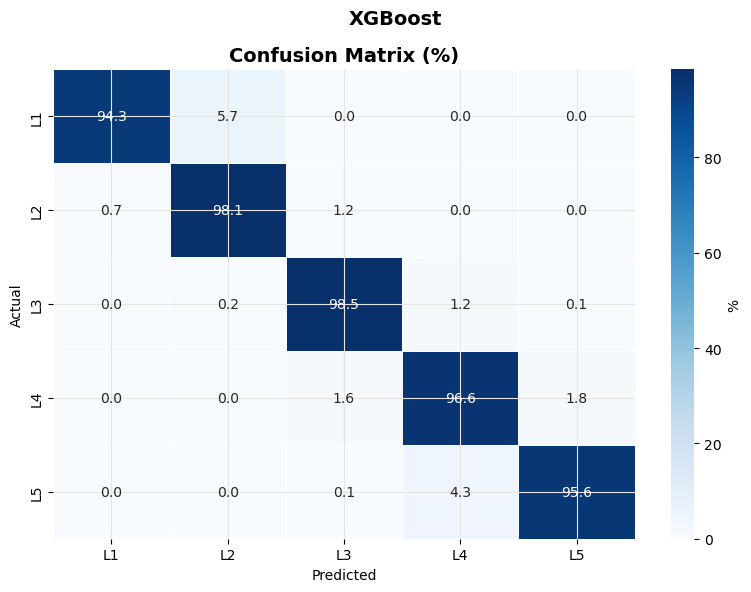

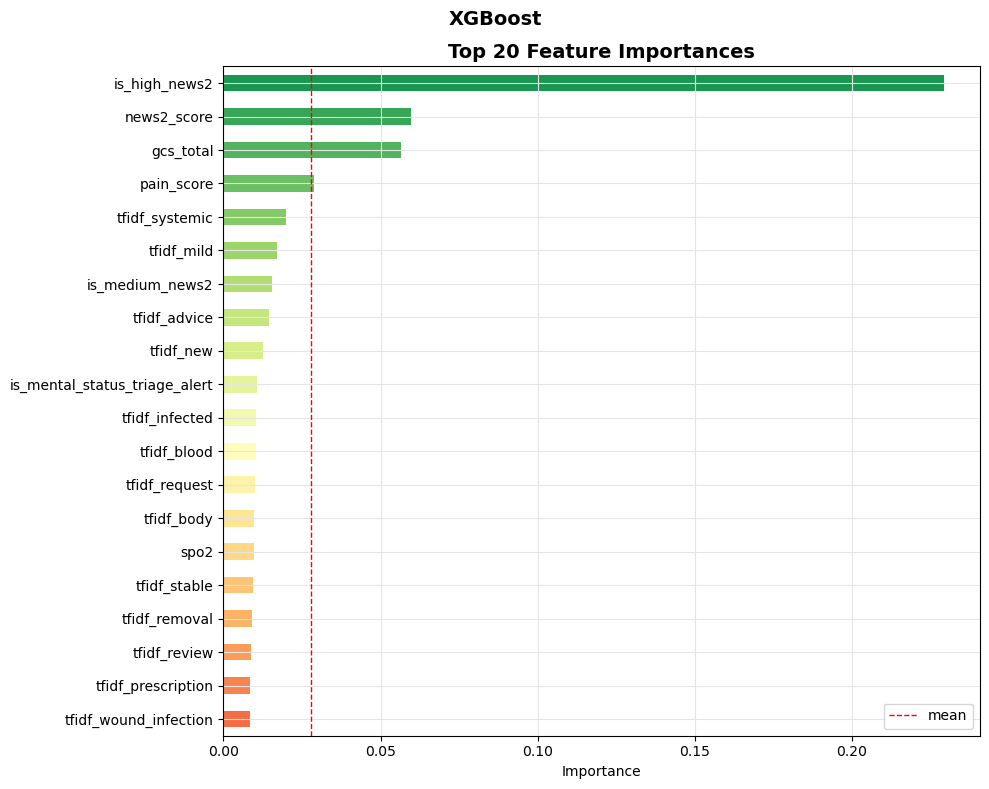

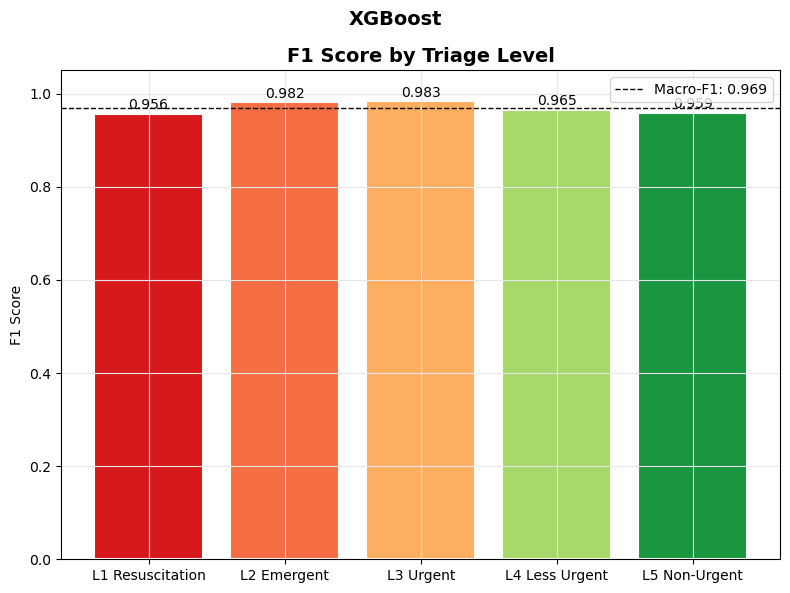

In [ ]:
from src.models import run_xgb

xgb_model, xgb_f1 = run_xgb(train_fe)

### LightGBM

  Accuracy  : 0.9761
  Macro-F1  : 0.9725
              precision    recall  f1-score   support

           1       0.98      0.95      0.96       644
           2       0.98      0.99      0.99      2688
           3       0.98      0.99      0.99      5784
           4       0.97      0.97      0.97      4604
           5       0.96      0.96      0.96      2280

    accuracy                           0.98     16000
   macro avg       0.98      0.97      0.97     16000
weighted avg       0.98      0.98      0.98     16000



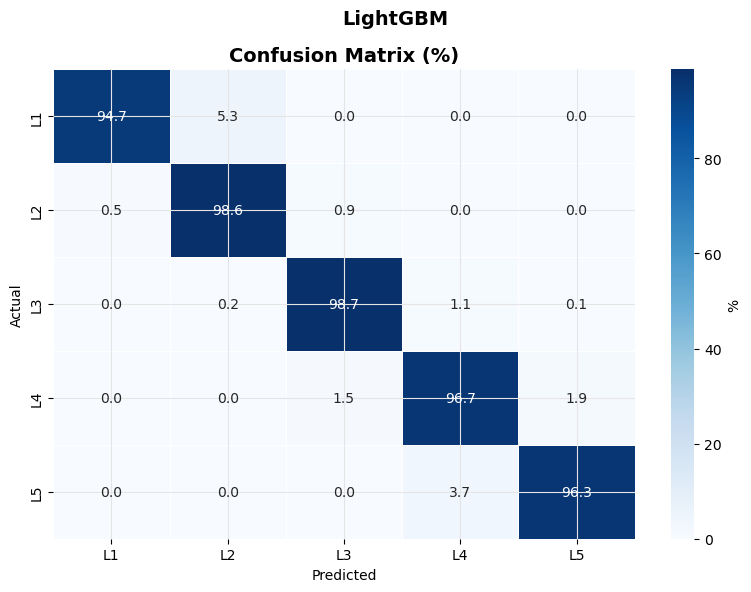

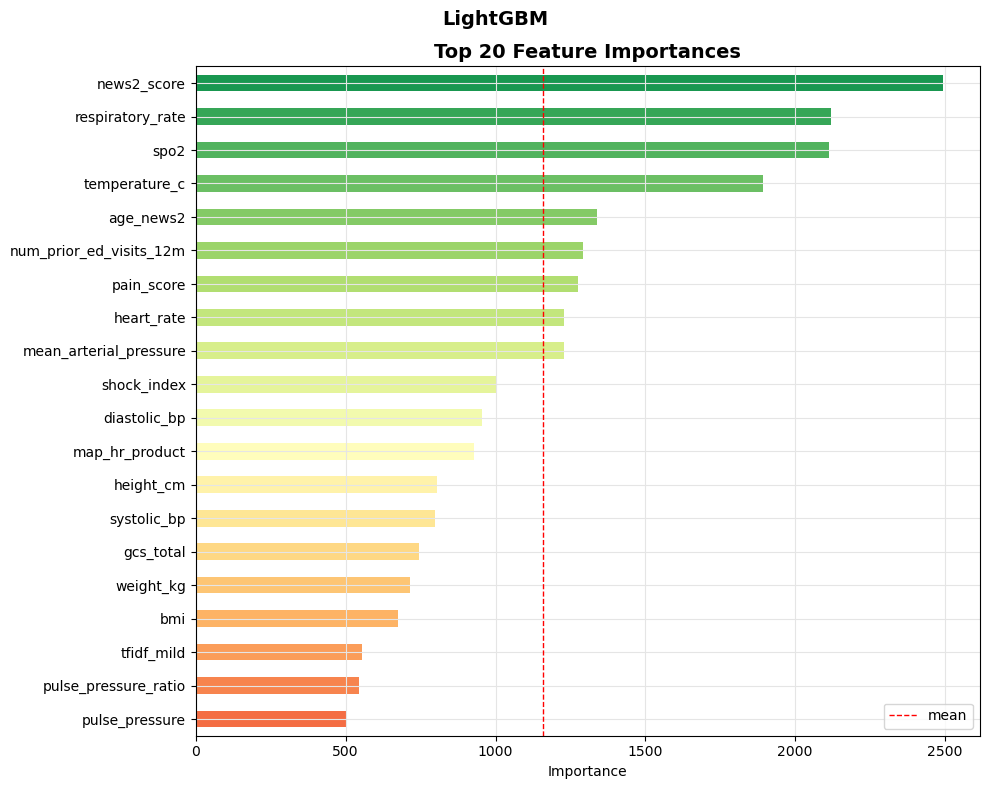

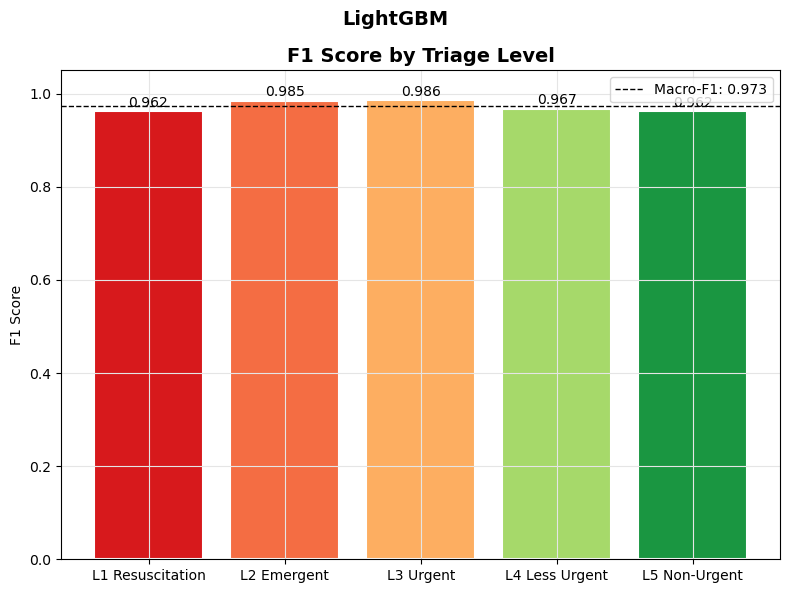

In [ ]:
from src.models import run_lgbm

lgbm_model, lgbm_f1 = run_lgbm(train_fe)

### Neural Network (MLP)

In [ ]:
from src.models import run_nn

nn_model, nn_scaler, nn_f1 = run_nn(
    train_fe,
    epochs=50, hidden_dims=(256, 128, 64), batch_size=512, lr=1e-3,
)

  Epoch  10/50  loss=0.0716


## Model Comparison

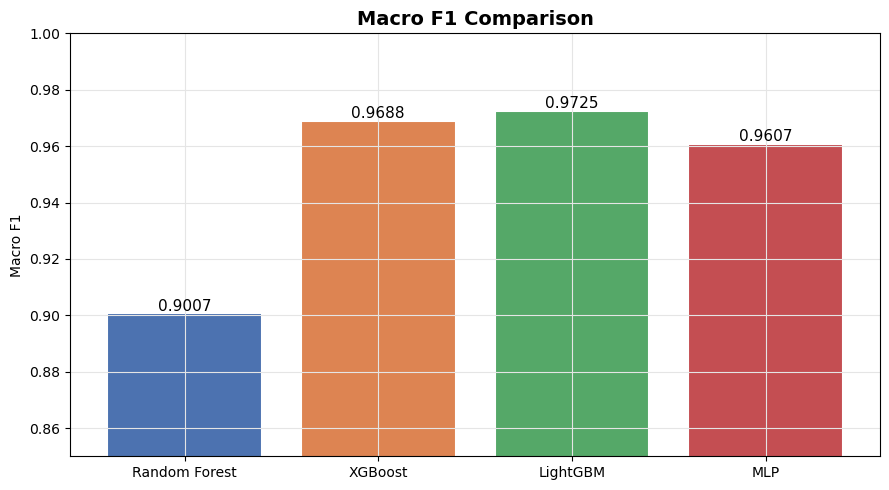


Best model: LightGBM  (0.9725)


In [ ]:
results = {
    'XGBoost':       xgb_f1,
    'LightGBM':      lgbm_f1,
    'MLP':           nn_f1,
}

fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(results.keys())
scores      = list(results.values())
colors      = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(model_names, scores, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylim(0.85, 1.0)
ax.set_title('Macro F1 Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Macro F1')
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2, score + 0.001,
            f'{score:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

best_name = max(results, key=results.get)
print(f'\nBest model: {best_name}  ({results[best_name]:.4f})')

## Submission

In [ ]:
import os
os.makedirs('submissions', exist_ok=True)

# Use the best model (LightGBM) â€” predictions are 0-indexed internally, shift back to 1-5
preds    = lgbm_model.predict(X_test) + 1
best_f1  = lgbm_f1
out_path = f'submissions/lightgbm_{best_f1:.4f}.csv'

sub = pd.DataFrame({'patient_id': test_raw['patient_id'], 'triage_acuity': preds})
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}  ({len(sub):,} rows)')
sub.head()

Saved: submissions/lightgbm_0.9725.csv  (20,000 rows)


,patient_id,triage_acuity
0,TG-FZUFCRZS3,2
1,TG-SSCOXTYI1,3
2,TG-JY74ZR35D,2
3,TG-JDKD5G62X,4
4,TG-J1BSAAXR0,4
